In [1]:
# =============================================================================
# SUPPLY CHAIN OPTIMIZATION — DataCo Global
# Notebook 01: EDA & Business Intelligence
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

SEED = 42
DATA_PATH = Path('../data')
IMG_PATH  = Path('../img')
IMG_PATH.mkdir(exist_ok=True)

PALETTE = {
    'primary'  : '#1A6FBF',
    'secondary': '#E8622A',
    'accent'   : '#5B4FCF',
    'success'  : '#2A9D5C',
    'warning'  : '#E8A020',
    'neutral'  : '#4A5568',
    'light'    : '#F7F9FC',
    'border'   : '#E2E8F0',
    'text'     : '#1A202C',
    'muted'    : '#718096',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : PALETTE['light'],
    'axes.edgecolor'   : PALETTE['border'],
    'axes.labelcolor'  : PALETTE['text'],
    'axes.titlecolor'  : PALETTE['text'],
    'xtick.color'      : PALETTE['neutral'],
    'ytick.color'      : PALETTE['neutral'],
    'text.color'       : PALETTE['text'],
    'grid.color'       : PALETTE['border'],
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.titleweight' : 'bold',
})

print("✅ Imports and config ready")

✅ Imports and config ready


In [2]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH / 'DataCoSupplyChainDataset.csv', encoding='latin-1')

print(f"✅ Data loaded")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"\nColumn types:")
print(df.dtypes.value_counts())
print(f"\nNulls per column (only cols with nulls):")
nulls = df.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))
print(f"\nSample:")
print(df.head(3))

✅ Data loaded
   Shape: 180,519 rows × 53 cols

Column types:
str        24
float64    15
int64      14
Name: count, dtype: int64

Nulls per column (only cols with nulls):
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Sample:
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0              91.25              314.64  Advance shipping   
1            -249.09              311.36     Late delivery   
2            -247.78              309.72  Shipping on time   

   Late_delivery_risk  Category Id   Category Name Customer City  \
0                   0           73  Sporting Goods        Caguas   
1           

In [3]:
# ── 2. CLEANING & PREPROCESSING ───────────────────────────────────────────────
# Drop columns with no analytical value
drop_cols = [
    'Product Description', 'Product Image', 'Customer Email',
    'Customer Password', 'Order Zipcode', 'Customer Street'
]
df.drop(columns=drop_cols, inplace=True)

# Parse dates
df['order date (DateOrders)']    = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Derived time features
df['order_year']  = df['order date (DateOrders)'].dt.year
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_quarter'] = df['order date (DateOrders)'].dt.quarter

# Delivery delay: real - scheduled
df['shipping_delay'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Binary: 1 = late, 0 = on time or early
df['is_late'] = (df['Delivery Status'] == 'Late delivery').astype(int)

# Clean nulls
df['Customer Zipcode'].fillna(0, inplace=True)
df.dropna(subset=['Customer Lname'], inplace=True)

print(f"✅ Data cleaned")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"   Date range: {df['order date (DateOrders)'].min().date()} → {df['order date (DateOrders)'].max().date()}")
print(f"   Markets: {df['Market'].unique()}")
print(f"   Shipping modes: {df['Shipping Mode'].unique()}")
print(f"   Late deliveries: {df['is_late'].sum():,} ({df['is_late'].mean():.1%} of orders)")
print(f"   Order statuses: {df['Order Status'].unique()}")

✅ Data cleaned
   Shape: 180,511 rows × 52 cols
   Date range: 2015-01-01 → 2018-01-31
   Markets: <ArrowStringArray>
['Pacific Asia', 'USCA', 'Africa', 'Europe', 'LATAM']
Length: 5, dtype: str
   Shipping modes: <ArrowStringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str
   Late deliveries: 98,973 (54.8% of orders)
   Order statuses: <ArrowStringArray>
[       'COMPLETE',         'PENDING',          'CLOSED', 'PENDING_PAYMENT',
        'CANCELED',      'PROCESSING', 'SUSPECTED_FRAUD',         'ON_HOLD',
  'PAYMENT_REVIEW']
Length: 9, dtype: str


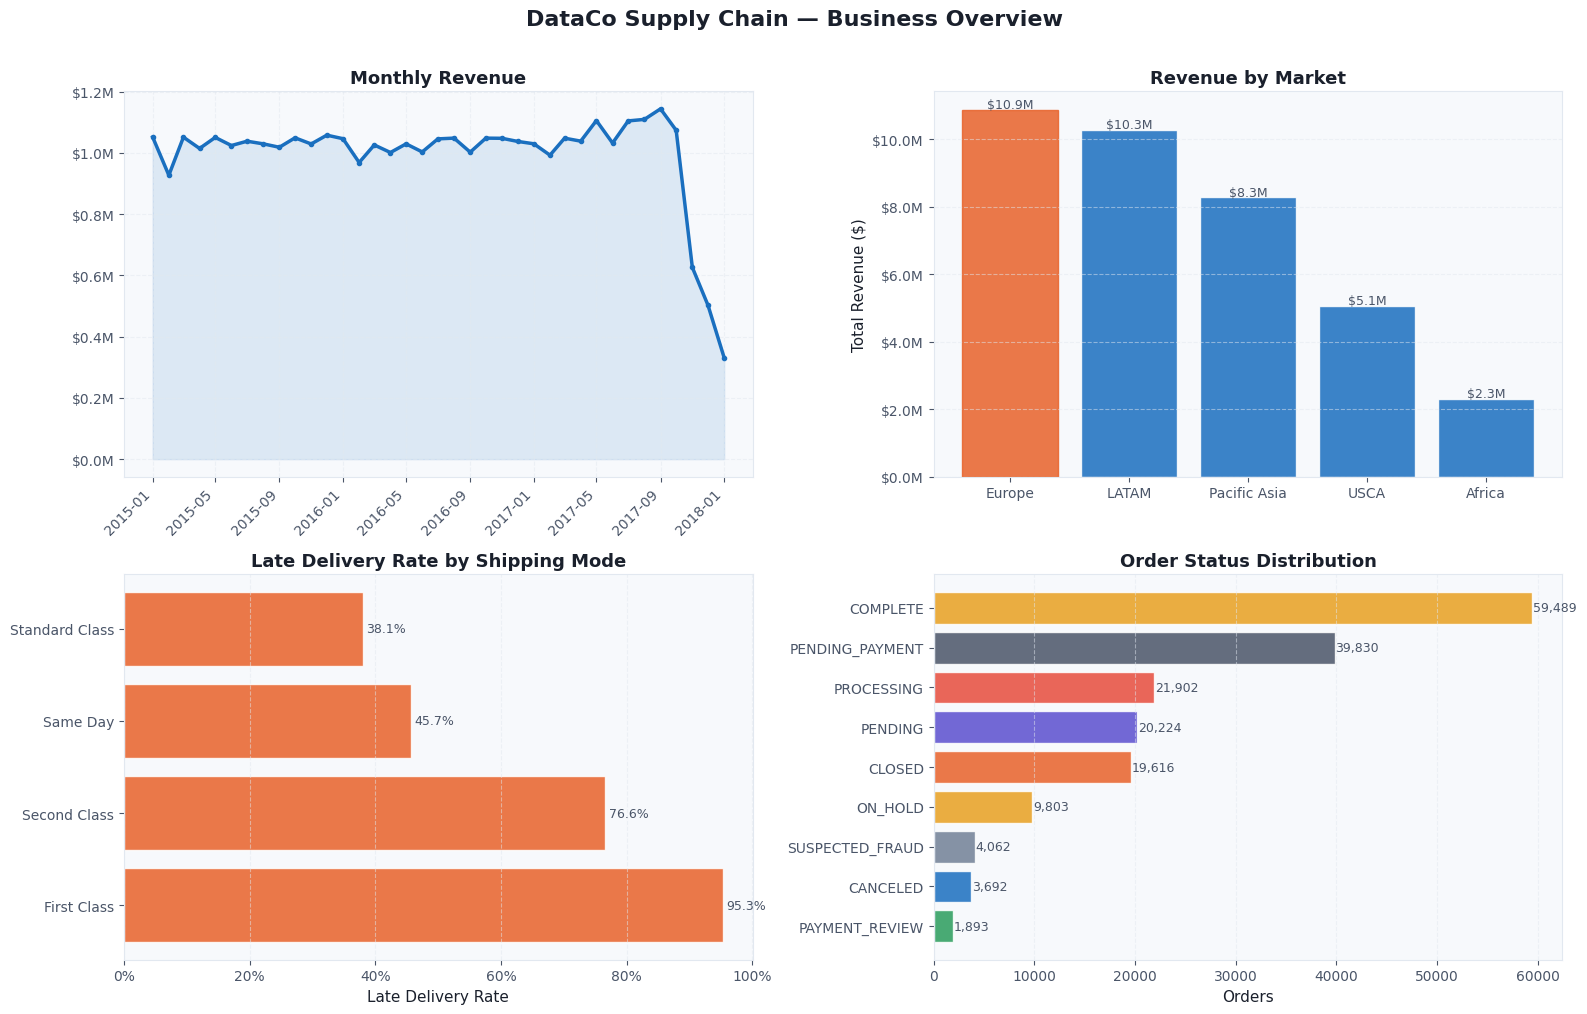

✅ Saved: eda_overview.png


In [5]:
# ── 3. BUSINESS OVERVIEW ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('DataCo Supply Chain — Business Overview', fontsize=16,
             fontweight='bold', color=PALETTE['text'], y=1.01)

# Monthly revenue trend
monthly = df.groupby(['order_year', 'order_month']).agg(
    revenue = ('Sales', 'sum'),
    orders  = ('Order Id', 'nunique')
).reset_index()
monthly['period'] = pd.to_datetime({'year': monthly['order_year'], 
                                     'month': monthly['order_month'], 
                                     'day': 1})
monthly = monthly.sort_values('period')

ax = axes[0, 0]
ax.plot(monthly['period'], monthly['revenue'],
        color=PALETTE['primary'], linewidth=2.5, marker='o', markersize=3)
ax.fill_between(monthly['period'], monthly['revenue'],
                alpha=0.12, color=PALETTE['primary'])
ax.set_title('Monthly Revenue')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.grid(True, alpha=0.5)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Revenue by market
market_rev = df.groupby('Market')['Sales'].sum().sort_values(ascending=False)
ax = axes[0, 1]
bars = ax.bar(market_rev.index, market_rev.values,
              color=PALETTE['primary'], alpha=0.85, edgecolor='white')
bars[0].set_color(PALETTE['secondary'])
ax.set_title('Revenue by Market')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, market_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${val/1e6:.1f}M', ha='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.5, axis='y')

# Late delivery by shipping mode
late_by_mode = df.groupby('Shipping Mode').agg(
    total  = ('is_late', 'count'),
    late   = ('is_late', 'sum')
).reset_index()
late_by_mode['late_rate'] = late_by_mode['late'] / late_by_mode['total']
late_by_mode = late_by_mode.sort_values('late_rate', ascending=False)

ax = axes[1, 0]
bars = ax.barh(late_by_mode['Shipping Mode'], late_by_mode['late_rate'],
               color=PALETTE['secondary'], alpha=0.85, edgecolor='white')
ax.set_title('Late Delivery Rate by Shipping Mode')
ax.set_xlabel('Late Delivery Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, late_by_mode['late_rate']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.5, axis='x')

# Order status distribution
status_counts = df['Order Status'].value_counts()
ax = axes[1, 1]
colors_status = [PALETTE['success'], PALETTE['primary'], PALETTE['muted'],
                 PALETTE['warning'], PALETTE['secondary'], PALETTE['accent'],
                 '#E74C3C', PALETTE['neutral'], PALETTE['warning']]
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1],
               color=colors_status[:len(status_counts)], alpha=0.85, edgecolor='white')
ax.set_title('Order Status Distribution')
ax.set_xlabel('Orders')
for bar, val in zip(bars, status_counts.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.5, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'eda_overview.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: eda_overview.png")

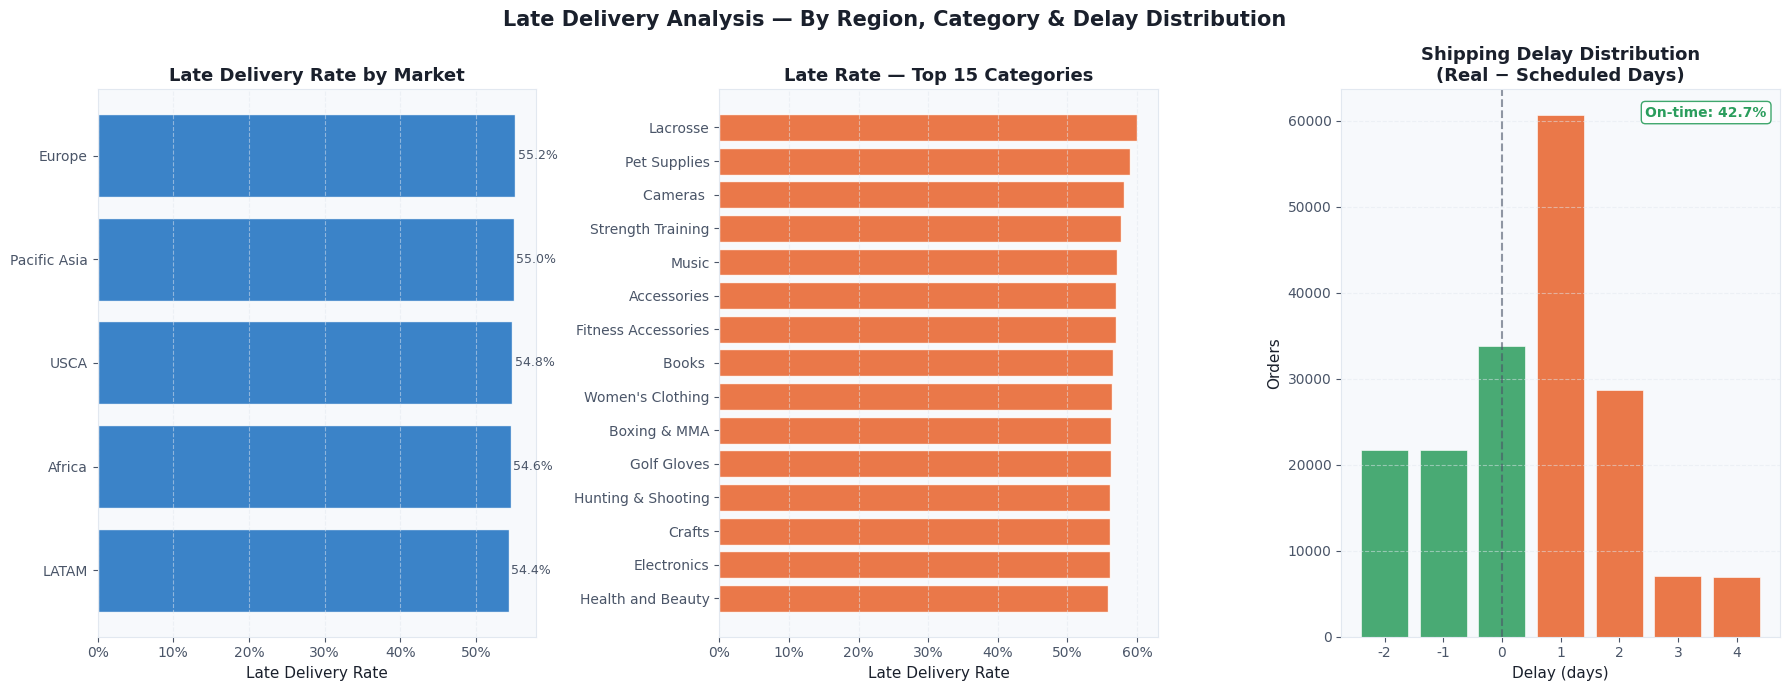

✅ Saved: late_delivery_analysis.png


In [6]:
# ── 4. LATE DELIVERY DEEP DIVE ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Late Delivery Analysis — By Region, Category & Delay Distribution',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Late rate by market
late_market = df.groupby('Market').agg(
    total = ('is_late', 'count'),
    late  = ('is_late', 'sum')
).reset_index()
late_market['late_rate'] = late_market['late'] / late_market['total']
late_market = late_market.sort_values('late_rate', ascending=True)

ax = axes[0]
bars = ax.barh(late_market['Market'], late_market['late_rate'],
               color=PALETTE['primary'], alpha=0.85, edgecolor='white')
ax.set_title('Late Delivery Rate by Market')
ax.set_xlabel('Late Delivery Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, late_market['late_rate']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.5, axis='x')

# Late rate by top 15 categories
late_cat = df.groupby('Category Name').agg(
    total = ('is_late', 'count'),
    late  = ('is_late', 'sum')
).reset_index()
late_cat['late_rate'] = late_cat['late'] / late_cat['total']
late_cat = late_cat[late_cat['total'] > 100].sort_values('late_rate', ascending=True).tail(15)

ax = axes[1]
ax.barh(late_cat['Category Name'], late_cat['late_rate'],
        color=PALETTE['secondary'], alpha=0.85, edgecolor='white')
ax.set_title('Late Rate — Top 15 Categories')
ax.set_xlabel('Late Delivery Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(True, alpha=0.5, axis='x')

# Shipping delay distribution
ax = axes[2]
delay_counts = df['shipping_delay'].value_counts().sort_index()
colors_delay = [PALETTE['success'] if x <= 0 else PALETTE['secondary'] 
                for x in delay_counts.index]
ax.bar(delay_counts.index.astype(str), delay_counts.values,
       color=colors_delay, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_title('Shipping Delay Distribution\n(Real − Scheduled Days)')
ax.set_xlabel('Delay (days)')
ax.set_ylabel('Orders')
ax.axvline(x=delay_counts.index.tolist().index(0), 
           color=PALETTE['neutral'], linestyle='--', alpha=0.6, linewidth=1.5)
on_time_pct = (df['shipping_delay'] <= 0).mean()
ax.text(0.97, 0.97, f'On-time: {on_time_pct:.1%}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        fontweight='bold', color=PALETTE['success'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=PALETTE['success'], alpha=0.9))
ax.grid(True, alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig(IMG_PATH / 'late_delivery_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: late_delivery_analysis.png")

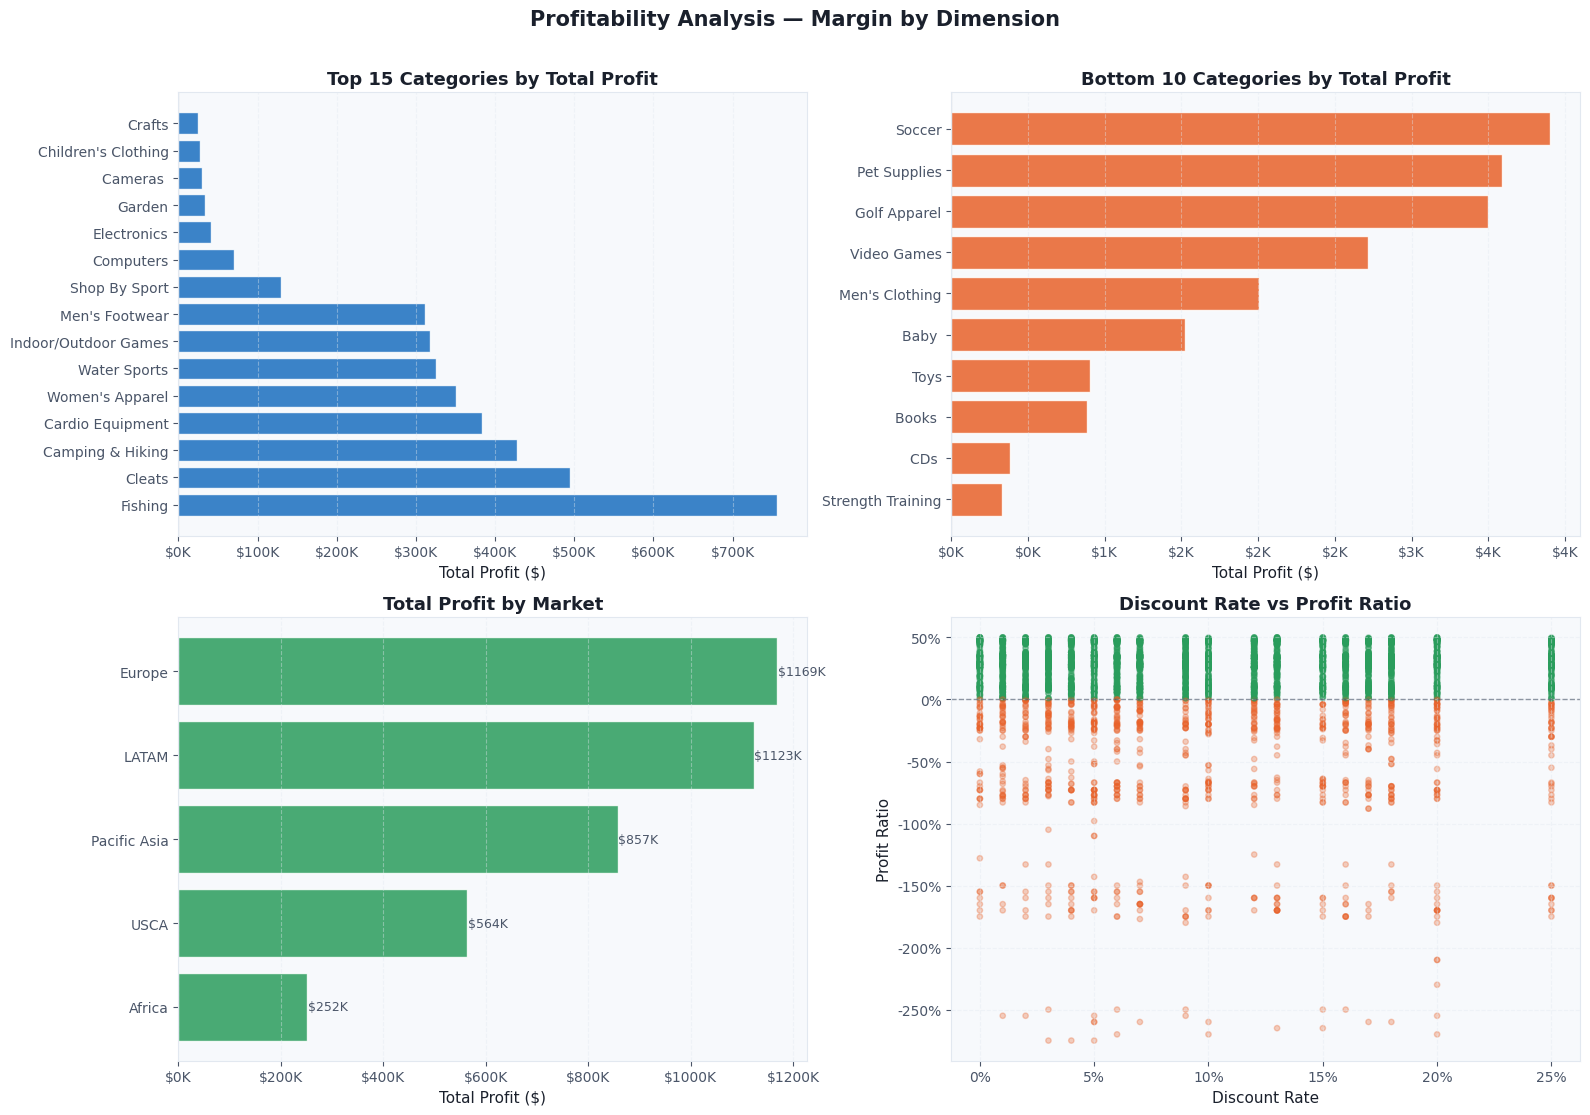

✅ Saved: profitability_analysis.png


In [7]:
# ── 5. PROFITABILITY ANALYSIS ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Profitability Analysis — Margin by Dimension',
             fontsize=15, fontweight='bold', color=PALETTE['text'], y=1.01)

# Profit by category (top 15 and bottom 10)
cat_profit = df.groupby('Category Name').agg(
    total_profit = ('Order Profit Per Order', 'sum'),
    avg_margin   = ('Order Item Profit Ratio', 'mean'),
    orders       = ('Order Id', 'count')
).reset_index()
cat_profit = cat_profit[cat_profit['orders'] > 100]

top15  = cat_profit.nlargest(15, 'total_profit')
bot10  = cat_profit.nsmallest(10, 'total_profit')

ax = axes[0, 0]
colors_top = [PALETTE['primary'] if v > 0 else PALETTE['secondary'] 
              for v in top15['total_profit']]
ax.barh(top15['Category Name'], top15['total_profit'],
        color=colors_top, alpha=0.85, edgecolor='white')
ax.set_title('Top 15 Categories by Total Profit')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.axvline(0, color=PALETTE['neutral'], linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.4, axis='x')

ax = axes[0, 1]
ax.barh(bot10['Category Name'], bot10['total_profit'],
        color=PALETTE['secondary'], alpha=0.85, edgecolor='white')
ax.set_title('Bottom 10 Categories by Total Profit')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.axvline(0, color=PALETTE['neutral'], linewidth=0.8, alpha=0.5)
ax.grid(True, alpha=0.4, axis='x')

# Profit by market
market_profit = df.groupby('Market').agg(
    total_profit = ('Order Profit Per Order', 'sum'),
    avg_margin   = ('Order Item Profit Ratio', 'mean')
).reset_index().sort_values('total_profit', ascending=True)

ax = axes[1, 0]
colors_mkt = [PALETTE['success'] if v > 0 else PALETTE['secondary']
              for v in market_profit['total_profit']]
bars = ax.barh(market_profit['Market'], market_profit['total_profit'],
               color=colors_mkt, alpha=0.85, edgecolor='white')
ax.set_title('Total Profit by Market')
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
for bar, val in zip(bars, market_profit['total_profit']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${val/1e3:.0f}K', va='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='x')

# Discount rate vs profit ratio
ax = axes[1, 1]
sample = df.sample(5000, random_state=SEED)
scatter_colors = [PALETTE['success'] if v > 0 else PALETTE['secondary']
                  for v in sample['Order Item Profit Ratio']]
ax.scatter(sample['Order Item Discount Rate'], sample['Order Item Profit Ratio'],
           c=scatter_colors, alpha=0.3, s=15)
ax.set_title('Discount Rate vs Profit Ratio')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit Ratio')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.axhline(0, color=PALETTE['neutral'], linewidth=1, linestyle='--', alpha=0.6)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(IMG_PATH / 'profitability_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: profitability_analysis.png")

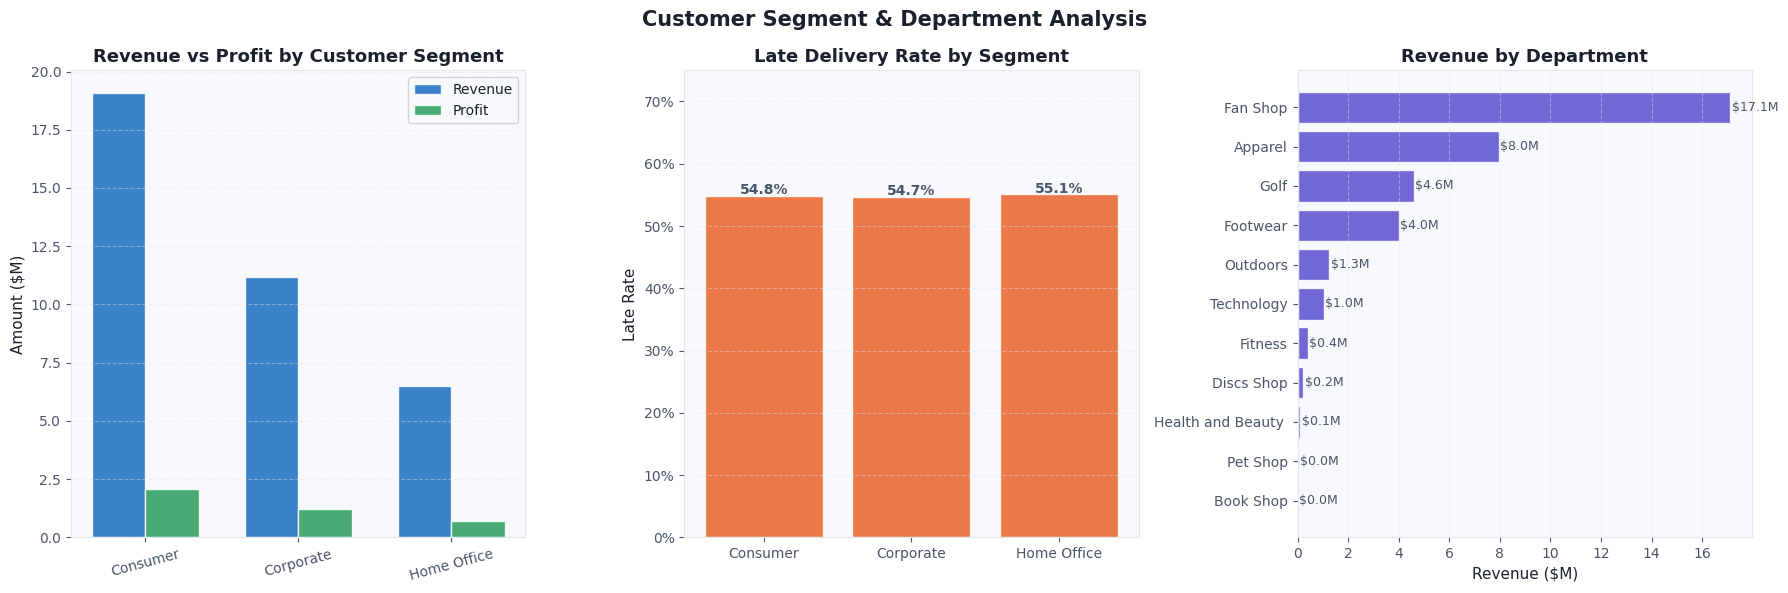

✅ Saved: customer_segment_analysis.png


In [8]:
# ── 6. CUSTOMER SEGMENT ANALYSIS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Segment & Department Analysis',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Revenue and profit by customer segment
seg_perf = df.groupby('Customer Segment').agg(
    revenue      = ('Sales', 'sum'),
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id', 'count'),
    late_rate    = ('is_late', 'mean')
).reset_index().sort_values('revenue', ascending=False)

ax = axes[0]
x     = np.arange(len(seg_perf))
width = 0.35
bars1 = ax.bar(x - width/2, seg_perf['revenue'] / 1e6, width,
               label='Revenue', color=PALETTE['primary'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, seg_perf['total_profit'] / 1e6, width,
               label='Profit', color=PALETTE['success'], alpha=0.85, edgecolor='white')
ax.set_title('Revenue vs Profit by Customer Segment')
ax.set_xticks(x)
ax.set_xticklabels(seg_perf['Customer Segment'], rotation=15)
ax.set_ylabel('Amount ($M)')
ax.legend()
ax.grid(True, alpha=0.4, axis='y')

# Late rate by customer segment
ax = axes[1]
bars = ax.bar(seg_perf['Customer Segment'], seg_perf['late_rate'],
              color=PALETTE['secondary'], alpha=0.85, edgecolor='white')
ax.set_title('Late Delivery Rate by Segment')
ax.set_ylabel('Late Rate')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
for bar, val in zip(bars, seg_perf['late_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', fontsize=10,
            fontweight='bold', color=PALETTE['neutral'])
ax.set_ylim(0, 0.75)
ax.grid(True, alpha=0.4, axis='y')

# Revenue by department
dept_rev = df.groupby('Department Name').agg(
    revenue      = ('Sales', 'sum'),
    total_profit = ('Order Profit Per Order', 'sum')
).reset_index().sort_values('revenue', ascending=True)

ax = axes[2]
bars = ax.barh(dept_rev['Department Name'], dept_rev['revenue'] / 1e6,
               color=PALETTE['accent'], alpha=0.85, edgecolor='white')
ax.set_title('Revenue by Department')
ax.set_xlabel('Revenue ($M)')
for bar, val in zip(bars, dept_rev['revenue'] / 1e6):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}M', va='center', fontsize=9, color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'customer_segment_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: customer_segment_analysis.png")

In [9]:
# ── 7. SAVE ARTIFACTS ─────────────────────────────────────────────────────────
import os
os.makedirs('../data/processed', exist_ok=True)

# Save clean master dataset
df.to_csv('../data/processed/supply_chain_clean.csv', index=False)

# Aggregated summaries for dashboard
market_summary = df.groupby('Market').agg(
    revenue      = ('Sales',                  'sum'),
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id',               'count'),
    late_orders  = ('is_late',                'sum'),
    late_rate    = ('is_late',                'mean'),
    avg_delay    = ('shipping_delay',         'mean')
).reset_index()

category_summary = df.groupby('Category Name').agg(
    revenue      = ('Sales',                  'sum'),
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id',               'count'),
    late_rate    = ('is_late',                'mean'),
    avg_margin   = ('Order Item Profit Ratio','mean'),
    avg_discount = ('Order Item Discount Rate','mean')
).reset_index()

shipping_summary = df.groupby('Shipping Mode').agg(
    orders    = ('Order Id',   'count'),
    late_rate = ('is_late',    'mean'),
    avg_delay = ('shipping_delay', 'mean'),
    revenue   = ('Sales',      'sum')
).reset_index()

segment_summary = df.groupby('Customer Segment').agg(
    revenue      = ('Sales',                  'sum'),
    total_profit = ('Order Profit Per Order', 'sum'),
    orders       = ('Order Id',               'count'),
    late_rate    = ('is_late',                'mean')
).reset_index()

market_summary.to_csv('../data/processed/market_summary.csv', index=False)
category_summary.to_csv('../data/processed/category_summary.csv', index=False)
shipping_summary.to_csv('../data/processed/shipping_summary.csv', index=False)
segment_summary.to_csv('../data/processed/segment_summary.csv', index=False)

print("✅ All artifacts saved to data/processed/")
print(f"   supply_chain_clean  → {len(df):,} rows × {df.shape[1]} cols")
print(f"   market_summary      → {len(market_summary)} markets")
print(f"   category_summary    → {len(category_summary)} categories")
print(f"   shipping_summary    → {len(shipping_summary)} shipping modes")
print(f"   segment_summary     → {len(segment_summary)} segments")
print(f"\nKey business metrics:")
print(f"   Total Revenue:      ${df['Sales'].sum():,.0f}")
print(f"   Total Profit:       ${df['Order Profit Per Order'].sum():,.0f}")
print(f"   Overall Margin:     {df['Order Profit Per Order'].sum() / df['Sales'].sum():.1%}")
print(f"   Late Deliveries:    {df['is_late'].sum():,} ({df['is_late'].mean():.1%})")
print(f"   Avg Shipping Delay: {df['shipping_delay'].mean():.2f} days")

✅ All artifacts saved to data/processed/
   supply_chain_clean  → 180,511 rows × 52 cols
   market_summary      → 5 markets
   category_summary    → 50 categories
   shipping_summary    → 4 shipping modes
   segment_summary     → 3 segments

Key business metrics:
   Total Revenue:      $36,781,952
   Total Profit:       $3,966,180
   Overall Margin:     10.8%
   Late Deliveries:    98,973 (54.8%)
   Avg Shipping Delay: 0.57 days
